In [2]:
## Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.dummy import DummyRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    median_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score,
    make_scorer
)

import joblib

# 1. Business Understanding

## Goal

The goal of this project is to estimate a developer's annual salary in USD using structured information from the Stack Overflow Developer Survey.

This notebook represents **Model Iteration 2**.

Compared with the first basic iteration, this iteration:

1. Keeps a much broader range of suitable structured features.
2. Removes identifiers, salary leakage, preference-based fields and open-text fields.
3. Separates multi-select answers before encoding.
4. Applies one-hot encoding to categorical features.
5. Applies StandardScaler before PCA.
6. Uses PCA to reduce the expanded feature space while retaining 95% of its variance.
7. Compares raw-salary and log-salary model versions.

PCA is tested as an improvement rather than assumed to be the final solution. Its performance will be compared using the same regression metrics as the earlier iteration.

# 2. Data Understanding

## 2.1 Load Dataset

In [3]:
## Read survey data into pandas DataFrame
FILE_PATH = "results.csv"

df = pd.read_csv(
    FILE_PATH,
    low_memory=False
)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (49191, 172)


,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to...,All skills. AI is a flop.,104413.0,9.0
2,3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",None of the above,10.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code;GitHub Copilot;Google Gemini,NaN,When I don’t trust AI’s answers;When I want to...,"Understand how things actually work, problem s...",53061.0,8.0
3,4,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,None of the above,4.0,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...","Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code,NaN,When I don’t trust AI’s answers;When I want to...,NaN,36197.0,6.0
4,5,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...","Caring for dependents (children, elderly, etc.)",21.0,"No, I am not new to coding and did not learn n...",NaN,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers,"critical thinking, the skill to define the tas...",60000.0,7.0


## 2.2 Summary Statistics

In [4]:
## Understand the type of variable for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49191 entries, 0 to 49190
Columns: 172 entries, ResponseId to JobSat
dtypes: float64(52), int64(1), object(119)
memory usage: 64.6+ MB


In [5]:
## Check for missing data
missing_summary = pd.DataFrame({
    "Missing Values": df.isna().sum(),
    "Missing Percentage": (
        df.isna().mean() * 100
    ).round(2)
}).sort_values(
    "Missing Percentage",
    ascending=False
)

missing_summary.head(20)

,Missing Values,Missing Percentage
AIAgentObsWrite,48927,99.46
SOTagsWant Entry,48761,99.13
SOTagsHaveEntry,48733,99.07
AIModelsWantEntry,48716,99.03
AIAgentOrchWrite,48713,99.03
JobSatPoints_15_TEXT,48527,98.65
AIAgentKnowWrite,48425,98.44
AIModelsHaveEntry,48415,98.42
SO_Actions_15_TEXT,48368,98.33
AIAgentExtWrite,48332,98.25


In [6]:
## Describe the target distribution
target_column = "ConvertedCompYearly"

df[target_column] = pd.to_numeric(
    df[target_column],
    errors="coerce"
)

df[target_column].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

count    2.394700e+04
mean     1.017615e+05
std      4.617569e+05
min      1.000000e+00
25%      3.817100e+04
50%      7.532000e+04
75%      1.205960e+05
90%      1.840000e+05
95%      2.320290e+05
99%      4.408560e+05
max      5.000000e+07
Name: ConvertedCompYearly, dtype: float64

## 2.3 Data Visualisation

### 2.3.1 Salary Distribution

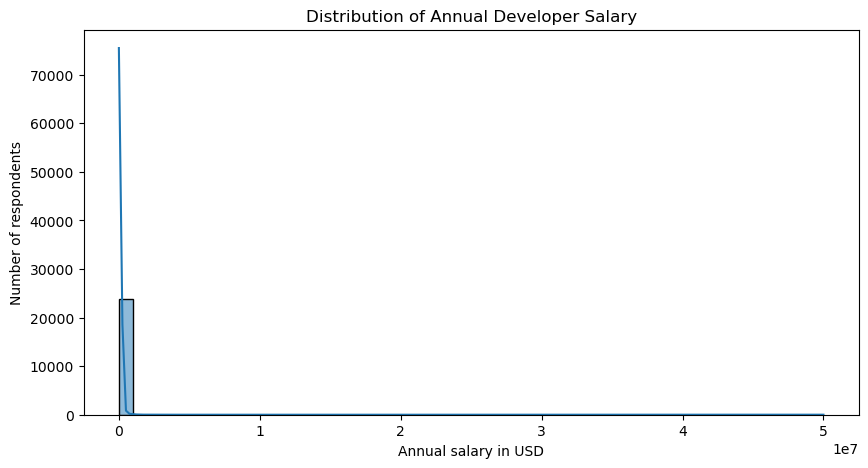

In [7]:
## Display the original salary distribution
plt.figure(figsize=(10, 5))

sns.histplot(
    df[target_column].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Annual Developer Salary")
plt.xlabel("Annual salary in USD")
plt.ylabel("Number of respondents")
plt.show()

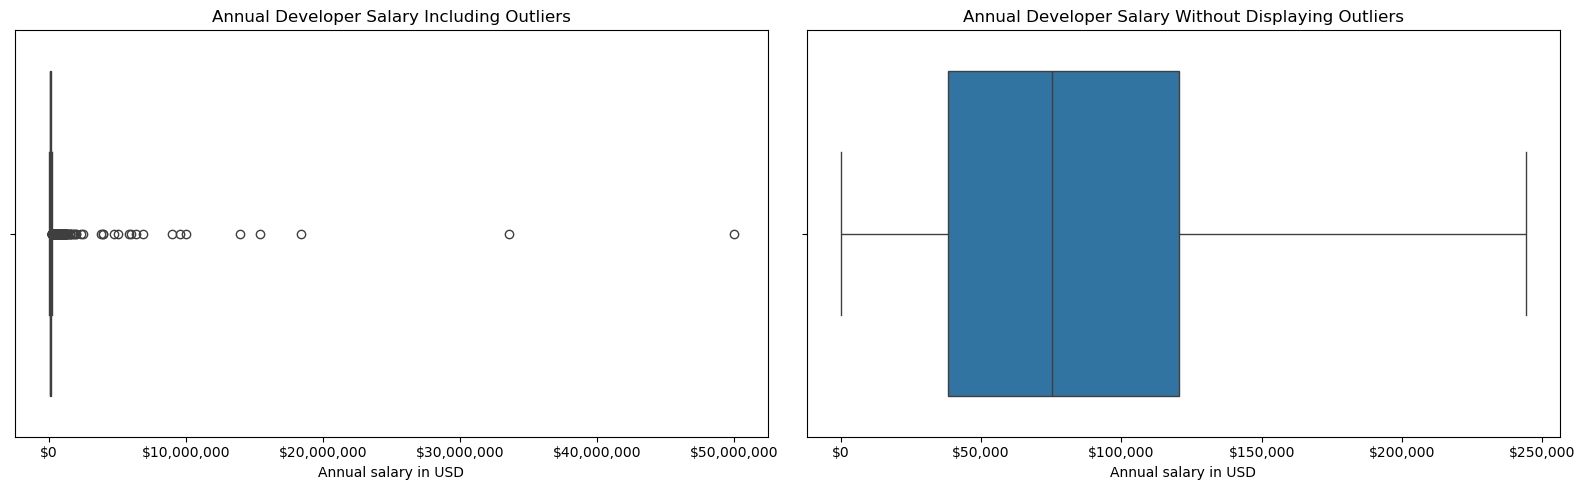

In [8]:
## Compare the complete distribution with the typical salary range
from matplotlib.ticker import StrMethodFormatter

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 5)
)

sns.boxplot(
    x=df[target_column],
    ax=axes[0]
)

axes[0].set_title(
    "Annual Developer Salary Including Outliers"
)
axes[0].set_xlabel(
    "Annual salary in USD"
)
axes[0].xaxis.set_major_formatter(
    StrMethodFormatter("${x:,.0f}")
)

sns.boxplot(
    x=df[target_column],
    showfliers=False,
    ax=axes[1]
)

axes[1].set_title(
    "Annual Developer Salary Without Displaying Outliers"
)
axes[1].set_xlabel(
    "Annual salary in USD"
)
axes[1].xaxis.set_major_formatter(
    StrMethodFormatter("${x:,.0f}")
)

plt.tight_layout()
plt.show()

# 3. Data Preparation

## 3.1 Define the Modelling Population

In [9]:
## Create a separate copy so that the original DataFrame remains unchanged
model_df = df.copy()

## Check the salary values before filtering
salary_checks = pd.Series({
    "Missing salary": model_df[target_column].isna().sum(),
    "Zero salary": (model_df[target_column] == 0).sum(),
    "Negative salary": (model_df[target_column] < 0).sum(),
    "Salary above USD 1 million": (
        model_df[target_column] > 1_000_000
    ).sum()
})

salary_checks

Missing salary                25244
Zero salary                       0
Negative salary                   0
Salary above USD 1 million       46
dtype: int64

In [10]:
## Keep employed respondents with a positive reported salary
##
## Zero and negative values are excluded because the application
## estimates positive annual compensation for paid employment.
##
## Large positive salaries are not automatically removed because
## they may still be valid. Their influence will later be reduced
## through a log-target experiment.

model_df = model_df[
    model_df["Employment"].eq("Employed")
    & model_df[target_column].notna()
    & (model_df[target_column] > 0)
].copy()

print(
    "Rows remaining for modelling:",
    len(model_df)
)

Rows remaining for modelling: 19500


## 3.2 Inspect Questionable Values

In [11]:
## Convert known numeric-like survey columns
numeric_like_columns = [
    "YearsCode",
    "WorkExp",
    "ToolCountWork",
    "ToolCountPersonal",
    "JobSat"
]

numeric_like_columns += [
    column
    for column in model_df.columns
    if column.startswith("JobSatPoints_")
]

for column in numeric_like_columns:
    if column in model_df.columns:
        model_df[column] = model_df[column].replace({
            "Less than 1 year": 0.5,
            "More than 50 years": 51
        })

        model_df[column] = pd.to_numeric(
            model_df[column],
            errors="coerce"
        )

In [12]:
## Flag unusual responses for investigation
## These records are not automatically deleted

model_df["QualityFlag"] = ""

if "YearsCode" in model_df.columns:
    model_df.loc[
        model_df["YearsCode"] > 70,
        "QualityFlag"
    ] += "Unusually high YearsCode; "

if "WorkExp" in model_df.columns:
    model_df.loc[
        model_df["WorkExp"] > 70,
        "QualityFlag"
    ] += "Unusually high WorkExp; "

model_df.loc[
    model_df[target_column] > 1_000_000,
    "QualityFlag"
] += "Salary above USD 1 million; "

quality_review = model_df[
    model_df["QualityFlag"] != ""
][
    [
        column
        for column in [
            "ResponseId",
            "YearsCode",
            "WorkExp",
            target_column,
            "QualityFlag"
        ]
        if column in model_df.columns
    ]
]

print(
    "Rows flagged for review:",
    len(quality_review)
)

quality_review.head(20)

Rows flagged for review: 39


,ResponseId,YearsCode,WorkExp,ConvertedCompYearly,QualityFlag
2009,2010,25.0,14.0,1006403.0,Salary above USD 1 million;
2668,2669,25.0,23.0,1300000.0,Salary above USD 1 million;
2725,2726,17.0,13.0,1250000.0,Salary above USD 1 million;
2812,2813,24.0,19.0,1200000.0,Salary above USD 1 million;
3265,3266,30.0,23.0,1500000.0,Salary above USD 1 million;
4583,4584,30.0,30.0,1160147.0,Salary above USD 1 million;
4842,4843,25.0,25.0,1100000.0,Salary above USD 1 million;
5327,5328,22.0,11.0,1950000.0,Salary above USD 1 million;
5410,5411,18.0,11.0,2346000.0,Salary above USD 1 million;
9310,9311,7.0,6.0,1500000.0,Salary above USD 1 million;


## 3.3 Select All Suitable Structured Features

In [13]:
## Remove columns that should not be model inputs

## Direct exclusions:
## - ResponseId is only an identifier.
## - Currency and CompTotal are directly involved in salary conversion.
## - ConvertedCompYearly is the target.
## - QualityFlag was created only for data-quality inspection.
direct_exclusions = [
    "ResponseId",
    "Currency",
    "CompTotal",
    target_column,
    "QualityFlag"
]

## Remove preference, desired-technology and open-text columns.
##
## Current experience columns such as LanguageHaveWorkedWith are kept.
## Preference columns such as LanguageAdmired and
## LanguageWantToWorkWith are removed.
excluded_keywords = [
    "_TEXT",
    "Admired",
    "WantTo",
    "WantEntry",
    "Choice"
]

candidate_features = []

for column in model_df.columns:
    if column in direct_exclusions:
        continue

    if any(
        keyword in column
        for keyword in excluded_keywords
    ):
        continue

    candidate_features.append(column)

print(
    "Candidate feature count:",
    len(candidate_features)
)

print("\nCandidate features:")
print(candidate_features)

Candidate feature count: 133

Candidate features:
['MainBranch', 'Age', 'EdLevel', 'Employment', 'EmploymentAddl', 'WorkExp', 'LearnCodeChoose', 'LearnCode', 'LearnCodeAI', 'AILearnHow', 'YearsCode', 'DevType', 'OrgSize', 'ICorPM', 'RemoteWork', 'PurchaseInfluence', 'TechEndorseIntro', 'TechEndorse_1', 'TechEndorse_2', 'TechEndorse_3', 'TechEndorse_4', 'TechEndorse_5', 'TechEndorse_6', 'TechEndorse_7', 'TechEndorse_8', 'TechEndorse_9', 'TechEndorse_13', 'TechOppose_1', 'TechOppose_2', 'TechOppose_3', 'TechOppose_5', 'TechOppose_7', 'TechOppose_9', 'TechOppose_11', 'TechOppose_13', 'TechOppose_16', 'TechOppose_15', 'Industry', 'JobSatPoints_1', 'JobSatPoints_2', 'JobSatPoints_3', 'JobSatPoints_4', 'JobSatPoints_5', 'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9', 'JobSatPoints_10', 'JobSatPoints_11', 'JobSatPoints_13', 'JobSatPoints_14', 'JobSatPoints_15', 'JobSatPoints_16', 'AIThreat', 'NewRole', 'ToolCountWork', 'ToolCountPersonal', 'Country', 'LanguageHaveWorke

In [14]:
## Separate the features and target
x = model_df[candidate_features].copy()
y = model_df[target_column].copy()

## Split before learning medians, categories, encodings, scaling or PCA
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=676767
)



## 3.4 Remove Unusable Columns Using Training Data

In [15]:
## Identify multi-select columns.
##
## Stack Overflow survey multi-select answers normally separate
## selected options using semicolons.

object_columns = x_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

multiselect_columns = []

for column in object_columns:
    contains_separator = (
        x_train[column]
        .dropna()
        .astype(str)
        .str.contains(";", regex=False)
        .any()
    )

    if contains_separator:
        multiselect_columns.append(column)

print(
    "Detected multi-select columns:",
    len(multiselect_columns)
)

print(multiselect_columns)

Detected multi-select columns: 45
['EmploymentAddl', 'LearnCode', 'AILearnHow', 'LanguageHaveWorkedWith', 'DatabaseHaveWorkedWith', 'DatabaseHaveEntry', 'PlatformHaveWorkedWith', 'WebframeHaveWorkedWith', 'DevEnvsHaveWorkedWith', 'DevEnvHaveEntry', 'SOTagsHaveWorkedWith', 'OpSysPersonal use', 'OpSysProfessional use', 'OfficeStackAsyncHaveWorkedWith', 'CommPlatformHaveWorkedWith', 'CommPlatformHaveEntr', 'CommPlatformWantEntr', 'AIModelsHaveWorkedWith', 'SO_Dev_Content', 'AIToolCurrently partially AI', "AIToolDon't plan to use AI for this task", 'AIToolPlan to partially use AI', 'AIToolPlan to mostly use AI', 'AIToolCurrently mostly AI', 'AIFrustration', 'AIExplain', 'AIAgent_Uses', 'AgentUsesGeneral', 'AIAgentImpactSomewhat agree', 'AIAgentImpactNeutral', 'AIAgentImpactSomewhat disagree', 'AIAgentImpactStrongly agree', 'AIAgentImpactStrongly disagree', 'AIAgentChallengesNeutral', 'AIAgentChallengesSomewhat disagree', 'AIAgentChallengesStrongly agree', 'AIAgentChallengesSomewhat agree',

In [16]:
## Remove columns that are unsuitable even before encoding
##
## 1. More than 85% missing in the training data
## 2. Only one unique value
## 3. Extremely high-cardinality ordinary categorical fields
##
## Multi-select columns are not removed by the high-cardinality
## rule because they will be split into separate binary options.

mostly_missing_columns = [
    column
    for column in x_train.columns
    if x_train[column].isna().mean() > 0.85
]

constant_columns = [
    column
    for column in x_train.columns
    if x_train[column].nunique(
        dropna=True
    ) <= 1
]

high_cardinality_columns = []

for column in object_columns:
    if column in multiselect_columns:
        continue

    if x_train[column].nunique(
        dropna=True
    ) > 250:
        high_cardinality_columns.append(column)

columns_to_remove = sorted(
    set(
        mostly_missing_columns
        + constant_columns
        + high_cardinality_columns
    )
)

x_train = x_train.drop(
    columns=columns_to_remove
)

x_test = x_test.drop(
    columns=columns_to_remove
)

multiselect_columns = [
    column
    for column in multiselect_columns
    if column in x_train.columns
]

print(
    "Columns removed:",
    len(columns_to_remove)
)

print(columns_to_remove)

print(
    "\nColumns remaining:",
    x_train.shape[1]
)

Columns removed: 20
['AIAgentExtWrite', 'AIAgentImpactStrongly disagree', 'AIAgentKnowWrite', 'AIAgentKnowledge', 'AIAgentObsWrite', 'AIAgentObserveSecure', 'AIAgentOrchWrite', 'AIAgentOrchestration', 'AIModelsHaveEntry', 'CommPlatformHaveEntr', 'CommPlatformWantEntr', 'DatabaseHaveEntry', 'DevEnvHaveEntry', 'Employment', 'LanguagesHaveEntry', 'OfficeStackHaveEntry', 'PlatformHaveEntry', 'SOTagsHaveEntry', 'SOTagsWant Entry', 'WebframeHaveEntry']

Columns remaining: 113


## 3.5 Encode All Remaining Features

In [17]:
## Identify numerical and ordinary categorical columns

numerical_columns = x_train.select_dtypes(
    include=["number", "bool"]
).columns.tolist()

categorical_columns = [
    column
    for column in x_train.select_dtypes(
        include=["object", "category"]
    ).columns
    if column not in multiselect_columns
]

print(
    "Numerical columns:",
    len(numerical_columns)
)

print(
    "Ordinary categorical columns:",
    len(categorical_columns)
)

print(
    "Multi-select columns:",
    len(multiselect_columns)
)

Numerical columns: 50
Ordinary categorical columns: 27
Multi-select columns: 36


In [18]:
## Prepare numerical features
##
## Missing numerical values are filled using medians learned
## from the training set only.

training_medians = {}

x_train_numeric = pd.DataFrame(
    index=x_train.index
)

x_test_numeric = pd.DataFrame(
    index=x_test.index
)

for column in numerical_columns:
    training_medians[column] = pd.to_numeric(
        x_train[column],
        errors="coerce"
    ).median()

    x_train_numeric[column] = pd.to_numeric(
        x_train[column],
        errors="coerce"
    ).fillna(
        training_medians[column]
    )

    x_test_numeric[column] = pd.to_numeric(
        x_test[column],
        errors="coerce"
    ).fillna(
        training_medians[column]
    )

In [19]:
## One-hot encode ordinary categorical columns
##
## The test set is reindexed to match the training columns.
## This prevents unseen test categories from changing the
## model input structure.

x_train_categorical = pd.get_dummies(
    x_train[categorical_columns].fillna(
        "Unknown"
    ).astype(str),
    drop_first=True,
    dtype=int
)

x_test_categorical = pd.get_dummies(
    x_test[categorical_columns].fillna(
        "Unknown"
    ).astype(str),
    drop_first=True,
    dtype=int
)

x_test_categorical = x_test_categorical.reindex(
    columns=x_train_categorical.columns,
    fill_value=0
)

print(
    "Ordinary OHE features:",
    x_train_categorical.shape[1]
)

Ordinary OHE features: 321


In [20]:
## Select an exact list of manageable features
##
## This iteration excludes:
## - Multi-select technology columns
## - Open-text columns
## - Very high-cardinality columns
## - Salary leakage columns
##
## Only these listed columns will be processed.

numerical_features = [
    "WorkExp",
    "YearsCode",
    "ToolCountWork",
    "ToolCountPersonal"
]

categorical_features = [
    "Age",
    "EdLevel",
    "RemoteWork",
    "OrgSize",
    "ICorPM",
    "PurchaseInfluence",
    "AIThreat",
    "NewRole",
    "SOAccount",
    "SOVisitFreq",
    "SODuration",
    "SOPartFreq",
    "SOComm",
    "SOFriction",
    "AISelect",
    "AISent"
]


## Keep only columns that actually exist in the dataset

numerical_features = [
    column
    for column in numerical_features
    if column in model_df.columns
]

categorical_features = [
    column
    for column in categorical_features
    if column in model_df.columns
]


selected_features = (
    numerical_features
    + categorical_features
)


print(
    "Numerical features selected:",
    numerical_features
)

print(
    "\nCategorical features selected:",
    categorical_features
)

print(
    "\nTotal original features selected:",
    len(selected_features)
)

Numerical features selected: ['WorkExp', 'YearsCode', 'ToolCountWork', 'ToolCountPersonal']

Categorical features selected: ['Age', 'EdLevel', 'RemoteWork', 'OrgSize', 'ICorPM', 'PurchaseInfluence', 'AIThreat', 'NewRole', 'SOAccount', 'SOVisitFreq', 'SODuration', 'SOPartFreq', 'SOComm', 'SOFriction', 'AISelect', 'AISent']

Total original features selected: 20


In [21]:
## Combine numerical, one-hot and multi-hot features

x_train_encoded = pd.concat(
    [
        x_train_numeric,
        x_train_categorical,
    ],
    axis=1
)

x_test_encoded = pd.concat(
    [
        x_test_numeric,
        x_test_categorical,
    ],
    axis=1
)

## Ensure the same column order
x_test_encoded = x_test_encoded.reindex(
    columns=x_train_encoded.columns,
    fill_value=0
)

## Convert all features into numeric values
x_train_encoded = x_train_encoded.astype(float)
x_test_encoded = x_test_encoded.astype(float)

## Remove encoded columns with no variation in the training data
zero_variance_encoded = [
    column
    for column in x_train_encoded.columns
    if x_train_encoded[column].nunique() <= 1
]

x_train_encoded = x_train_encoded.drop(
    columns=zero_variance_encoded
)

x_test_encoded = x_test_encoded.drop(
    columns=zero_variance_encoded
)

print(
    "Original proper columns:",
    x_train.shape[1]
)

print(
    "Features after OHE and multi-hot encoding:",
    x_train_encoded.shape[1]
)

print(
    "Training encoded shape:",
    x_train_encoded.shape
)

print(
    "Testing encoded shape:",
    x_test_encoded.shape
)

Original proper columns: 113
Features after OHE and multi-hot encoding: 371
Training encoded shape: (15600, 371)
Testing encoded shape: (3900, 371)


## 3.6 Standardise Features and Apply PCA

In [22]:
## Standardise the encoded features
##
## PCA is affected by feature scale. StandardScaler prevents
## large numerical ranges from dominating the components.

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(
    x_train_encoded
)

x_test_scaled = scaler.transform(
    x_test_encoded
)

print(
    "Scaled training shape:",
    x_train_scaled.shape
)

Scaled training shape: (15600, 371)


In [23]:
## Apply PCA and retain 95% of the input-feature variance
##
## PCA is fitted only on the training set.
## The test set is transformed using the fitted PCA object.

pca = PCA(
    n_components=0.95,
    svd_solver="full"
)

x_train_pca = pca.fit_transform(
    x_train_scaled
)

x_test_pca = pca.transform(
    x_test_scaled
)

print(
    "Features before PCA:",
    x_train_encoded.shape[1]
)

print(
    "Components after PCA:",
    x_train_pca.shape[1]
)

print(
    "Variance retained:",
    round(
        pca.explained_variance_ratio_.sum(),
        4
    )
)

reduction_percentage = (
    1
    - (
        x_train_pca.shape[1]
        / x_train_encoded.shape[1]
    )
) * 100


Features before PCA: 371
Components after PCA: 310
Variance retained: 0.9511


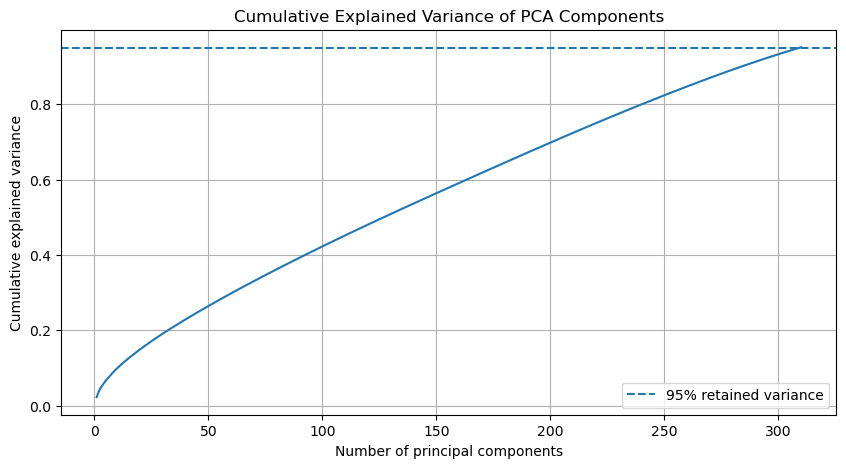

In [24]:
## Display cumulative explained variance

cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

plt.figure(figsize=(10, 5))

plt.plot(
    range(
        1,
        len(cumulative_variance) + 1
    ),
    cumulative_variance
)

plt.axhline(
    y=0.95,
    linestyle="--",
    label="95% retained variance"
)

plt.title(
    "Cumulative Explained Variance of PCA Components"
)

plt.xlabel(
    "Number of principal components"
)

plt.ylabel(
    "Cumulative explained variance"
)

plt.legend()
plt.grid()
plt.show()

# 4. Modelling

## 4.1 Evaluation Function

In [25]:
## Store all model results in one list
model_results = []

def evaluate_regression(
    model_name,
    actual_values,
    predicted_values
):
    predicted_values = np.maximum(
        predicted_values,
        0
    )

    result = {
        "Model": model_name,
        "MAE": mean_absolute_error(
            actual_values,
            predicted_values
        ),
        "Median Absolute Error": (
            median_absolute_error(
                actual_values,
                predicted_values
            )
        ),
        "MSE": mean_squared_error(
            actual_values,
            predicted_values
        ),
        "RMSE": root_mean_squared_error(
            actual_values,
            predicted_values
        ),
        "R2": r2_score(
            actual_values,
            predicted_values
        )
    }

    model_results.append(result)

    return result

## 4.2 Baseline Model

In [26]:
## Initialise and train the baseline model
##
## The median baseline is suitable for MAE because salary
## contains a strongly right-skewed distribution.

baseline = DummyRegressor(
    strategy="median"
)

baseline.fit(
    x_train_pca,
    y_train
)

y_pred_baseline = baseline.predict(
    x_test_pca
)

evaluate_regression(
    "Median Baseline",
    y_test,
    y_pred_baseline
)

{'Model': 'Median Baseline',
 'MAE': 58726.58974358974,
 'Median Absolute Error': 40826.0,
 'MSE': 19894522047.764614,
 'RMSE': 141047.94237338103,
 'R2': -0.018247690798921967}

## 4.3 Train Models Using Expanded Features and PCA

In [27]:
## Initialise and train Decision Tree model

decision_tree_pca = DecisionTreeRegressor(
    random_state=67
)

decision_tree_pca.fit(
    x_train_pca,
    y_train
)

y_pred_tree_pca = decision_tree_pca.predict(
    x_test_pca
)

evaluate_regression(
    "Decision Tree - Expanded Features + PCA",
    y_test,
    y_pred_tree_pca
)

{'Model': 'Decision Tree - Expanded Features + PCA',
 'MAE': 77966.62897435897,
 'Median Absolute Error': 40259.5,
 'MSE': 148388535645.00693,
 'RMSE': 385212.32540640095,
 'R2': -6.594868748231088}

In [28]:
## Initialise and train Random Forest model

random_forest_pca = RandomForestRegressor(
    n_estimators=100,
    random_state=67,
    n_jobs=-1
)

random_forest_pca.fit(
    x_train_pca,
    y_train
)

y_pred_forest_pca = random_forest_pca.predict(
    x_test_pca
)

evaluate_regression(
    "Random Forest - Expanded Features + PCA",
    y_test,
    y_pred_forest_pca
)

{'Model': 'Random Forest - Expanded Features + PCA',
 'MAE': 61496.88362820513,
 'Median Absolute Error': 30886.415000000005,
 'MSE': 72612055844.93993,
 'RMSE': 269466.24249604985,
 'R2': -2.7164531025554415}

In [29]:
## Initialise and train Gradient Boosting model

gradient_boosting_pca = GradientBoostingRegressor(
    random_state=67
)

gradient_boosting_pca.fit(
    x_train_pca,
    y_train
)

y_pred_gradient_pca = gradient_boosting_pca.predict(
    x_test_pca
)

evaluate_regression(
    "Gradient Boosting - Expanded Features + PCA",
    y_test,
    y_pred_gradient_pca
)

{'Model': 'Gradient Boosting - Expanded Features + PCA',
 'MAE': 58269.26549011874,
 'Median Absolute Error': 30267.170207985786,
 'MSE': 91405389070.40538,
 'RMSE': 302333.2417555261,
 'R2': -3.6783394003665038}

## 4.4 Log-Target Experiment

In [30]:
## Transform only the training target
##
## log1p reduces the influence of extremely large salaries.
## Predictions are converted back into normal USD using expm1.

y_train_log = np.log1p(
    y_train
)

gradient_boosting_pca_log = GradientBoostingRegressor(
    loss="huber",
    random_state=67
)

gradient_boosting_pca_log.fit(
    x_train_pca,
    y_train_log
)

y_pred_gradient_pca_log = np.expm1(
    gradient_boosting_pca_log.predict(
        x_test_pca
    )
)

evaluate_regression(
    "Gradient Boosting - Expanded Features + PCA + Log Target",
    y_test,
    y_pred_gradient_pca_log
)

{'Model': 'Gradient Boosting - Expanded Features + PCA + Log Target',
 'MAE': 41018.749069474754,
 'Median Absolute Error': 22784.33943293987,
 'MSE': 17355035970.76458,
 'RMSE': 131738.51361983927,
 'R2': 0.11172908509511603}

# 5. Model Evaluation

In [31]:
## Compare all models

results = pd.DataFrame(
    model_results
).sort_values(
    "MAE"
).reset_index(
    drop=True
)

baseline_mae = results.loc[
    results["Model"].eq(
        "Median Baseline"
    ),
    "MAE"
].iloc[0]

results[
    "MAE Improvement vs Baseline (%)"
] = (
    (
        baseline_mae
        - results["MAE"]
    )
    / baseline_mae
    * 100
)

results

,Model,MAE,Median Absolute Error,MSE,RMSE,R2,MAE Improvement vs Baseline (%)
0,Gradient Boosting - Expanded Features + PCA + ...,41018.749069,22784.339433,1.735504e+10,131738.513620,0.111729,30.153021
1,Gradient Boosting - Expanded Features + PCA,58269.265490,30267.170208,9.140539e+10,302333.241756,-3.678339,0.778735
2,Median Baseline,58726.589744,40826.000000,1.989452e+10,141047.942373,-0.018248,0.000000
3,Random Forest - Expanded Features + PCA,61496.883628,30886.415000,7.261206e+10,269466.242496,-2.716453,-4.717274
4,Decision Tree - Expanded Features + PCA,77966.628974,40259.500000,1.483885e+11,385212.325406,-6.594869,-32.762058


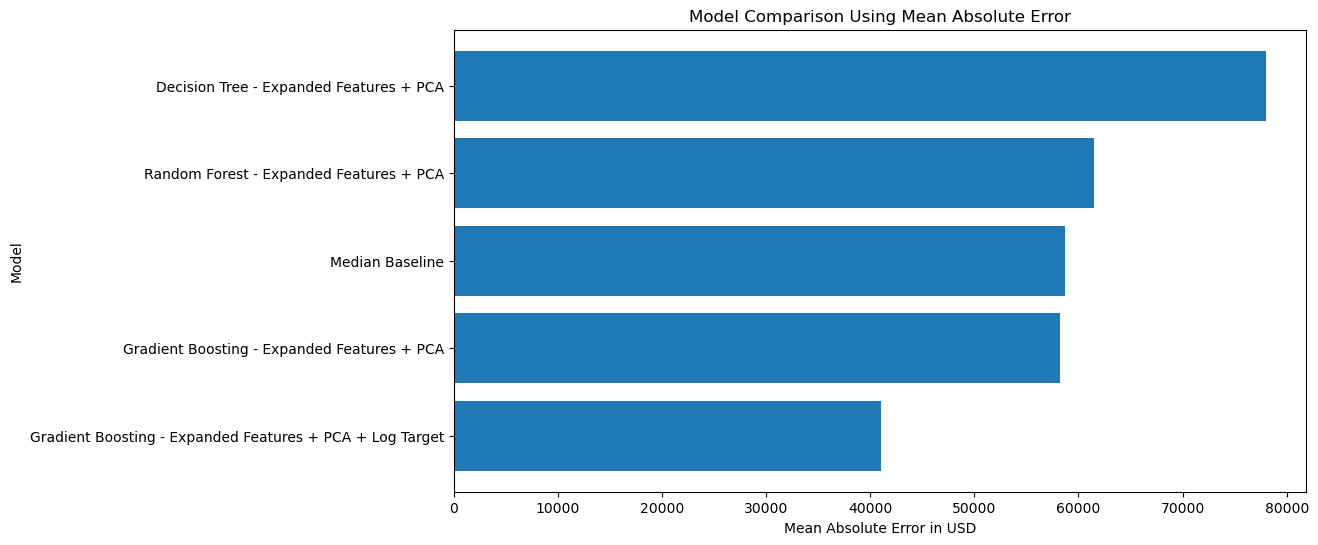

In [32]:
## Visualise model MAE

plt.figure(figsize=(11, 6))

ordered_results = results.sort_values(
    "MAE",
    ascending=True
)

plt.barh(
    ordered_results["Model"],
    ordered_results["MAE"]
)

plt.title(
    "Model Comparison Using Mean Absolute Error"
)

plt.xlabel(
    "Mean Absolute Error in USD"
)

plt.ylabel(
    "Model"
)

plt.show()

## 5.1 Understand the PCA Components

In [33]:
## Create a loading table linking PCA components
## back to the original encoded features

component_names = [
    f"PC{number}"
    for number in range(
        1,
        pca.n_components_ + 1
    )
]

pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=x_train_encoded.columns,
    columns=component_names
)

## Display the strongest original features for the
## first three components

for component in component_names[:3]:
    print(
        f"\nTop features contributing to {component}:"
    )

    display(
        pca_loadings[component]
        .abs()
        .sort_values(
            ascending=False
        )
        .head(10)
    )


Top features contributing to PC1:


SOComm_Unknown           0.296663
SOPartFreq_Unknown       0.285791
SOFriction_Unknown       0.276219
SOVisitFreq_Unknown      0.275552
SOAccount_Unknown        0.273134
SODuration_Unknown       0.272454
AIAgents_Unknown         0.261652
AIAgentChange_Unknown    0.258624
AIComplex_Unknown        0.251265
AIAcc_Unknown            0.250958
Name: PC1, dtype: float64


Top features contributing to PC2:


AISelect_Yes, I use AI tools daily                                 0.291809
SOFriction_I don't use AI or AI-enabled tools                      0.238889
AISent_Very favorable                                              0.232466
AIAgentChange_Not at all or minimally                              0.231082
AIAgents_No, and I don't plan to                                   0.228485
AIAcc_Somewhat trust                                               0.207116
AIAgentChange_Yes, to a great extent                               0.202916
AIComplex_I don't use AI tools for complex tasks / I don't know    0.202631
AIComplex_Good, but not great at handling complex tasks            0.202401
TechEndorse_1                                                      0.200904
Name: PC2, dtype: float64


Top features contributing to PC3:


WorkExp                                                                   0.392049
YearsCode                                                                 0.375802
Age_25-34 years old                                                       0.271396
Age_45-54 years old                                                       0.211699
SOPartFreq_I have never participated in Q&A on Stack Overflow             0.195934
SODuration_More than 15 years, or since Stack Overflow started in 2008    0.192707
Age_55-64 years old                                                       0.163473
SODuration_Between 5 and 10 years                                         0.162079
SODuration_Between 10 and 15 years                                        0.147058
SOAccount_Yes                                                             0.143617
Name: PC3, dtype: float64

## 5.2 Hyperparameter Tuning

In [34]:
## Tune Gradient Boosting using the PCA features
##
## Each hyperparameter contains no more than three choices.
##
## The custom scorer converts log predictions back into USD
## so that cross-validation still compares models using salary MAE.

def salary_mae_from_log(
    actual_log_salary,
    predicted_log_salary
):
    actual_salary = np.expm1(
        actual_log_salary
    )

    predicted_salary = np.expm1(
        predicted_log_salary
    )

    return mean_absolute_error(
        actual_salary,
        predicted_salary
    )


salary_mae_scorer = make_scorer(
    salary_mae_from_log,
    greater_is_better=False
)

parameter_options = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.03, 0.05, 0.10],
    "max_depth": [2, 3, 4],
    "min_samples_split": [2, 5, 10]
}

gradient_for_tuning = GradientBoostingRegressor(
    loss="huber",
    random_state=67
)

random_search = RandomizedSearchCV(
    estimator=gradient_for_tuning,
    param_distributions=parameter_options,
    n_iter=10,
    scoring=salary_mae_scorer,
    cv=3,
    random_state=67,
    n_jobs=-1
)

random_search.fit(
    x_train_pca,
    y_train_log
)

print(
    "Best hyperparameters:"
)

print(
    random_search.best_params_
)

Best hyperparameters:
{'n_estimators': 300, 'min_samples_split': 2, 'max_depth': 3, 'learning_rate': 0.05}


In [35]:
## Display the tuning logs

tuning_results = pd.DataFrame(
    random_search.cv_results_
)[
    [
        "params",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].copy()

tuning_results = tuning_results.sort_values(
    "rank_test_score"
)

tuning_results.head(10)

,params,mean_test_score,std_test_score,rank_test_score
8,"{'n_estimators': 300, 'min_samples_split': 2, ...",-44959.558009,6449.133200,1
1,"{'n_estimators': 300, 'min_samples_split': 2, ...",-45061.968985,6475.255106,2
3,"{'n_estimators': 100, 'min_samples_split': 5, ...",-46277.287284,6536.204949,3
6,"{'n_estimators': 300, 'min_samples_split': 2, ...",-46503.136407,6545.259371,4
7,"{'n_estimators': 300, 'min_samples_split': 2, ...",-46924.041074,6501.897351,5
5,"{'n_estimators': 200, 'min_samples_split': 2, ...",-47933.385640,6515.254625,6
9,"{'n_estimators': 100, 'min_samples_split': 5, ...",-48292.551139,6542.444295,7
2,"{'n_estimators': 100, 'min_samples_split': 5, ...",-49234.316446,6393.906966,8
4,"{'n_estimators': 200, 'min_samples_split': 5, ...",-50070.077470,6480.228123,9
0,"{'n_estimators': 100, 'min_samples_split': 2, ...",-52703.603050,6396.295909,10


In [36]:
## Evaluate the tuned model in the original USD scale

best_model = random_search.best_estimator_

y_pred_tuned = np.expm1(
    best_model.predict(
        x_test_pca
    )
)

tuned_result = {
    "Model": (
        "Tuned Gradient Boosting - "
        "Expanded Features + PCA + Log Target"
    ),
    "MAE": mean_absolute_error(
        y_test,
        y_pred_tuned
    ),
    "Median Absolute Error": (
        median_absolute_error(
            y_test,
            y_pred_tuned
        )
    ),
    "MSE": mean_squared_error(
        y_test,
        y_pred_tuned
    ),
    "RMSE": root_mean_squared_error(
        y_test,
        y_pred_tuned
    ),
    "R2": r2_score(
        y_test,
        y_pred_tuned
    )
}

final_results = pd.concat(
    [
        results,
        pd.DataFrame(
            [tuned_result]
        )
    ],
    ignore_index=True
).sort_values(
    "MAE"
).reset_index(
    drop=True
)

final_results

,Model,MAE,Median Absolute Error,MSE,RMSE,R2,MAE Improvement vs Baseline (%)
0,Tuned Gradient Boosting - Expanded Features + ...,39540.305923,21317.220758,1.705500e+10,130594.777530,0.127086,NaN
1,Gradient Boosting - Expanded Features + PCA + ...,41018.749069,22784.339433,1.735504e+10,131738.513620,0.111729,30.153021
2,Gradient Boosting - Expanded Features + PCA,58269.265490,30267.170208,9.140539e+10,302333.241756,-3.678339,0.778735
3,Median Baseline,58726.589744,40826.000000,1.989452e+10,141047.942373,-0.018248,0.000000
4,Random Forest - Expanded Features + PCA,61496.883628,30886.415000,7.261206e+10,269466.242496,-2.716453,-4.717274
5,Decision Tree - Expanded Features + PCA,77966.628974,40259.500000,1.483885e+11,385212.325406,-6.594869,-32.762058


## 5.3 Visual Evaluation

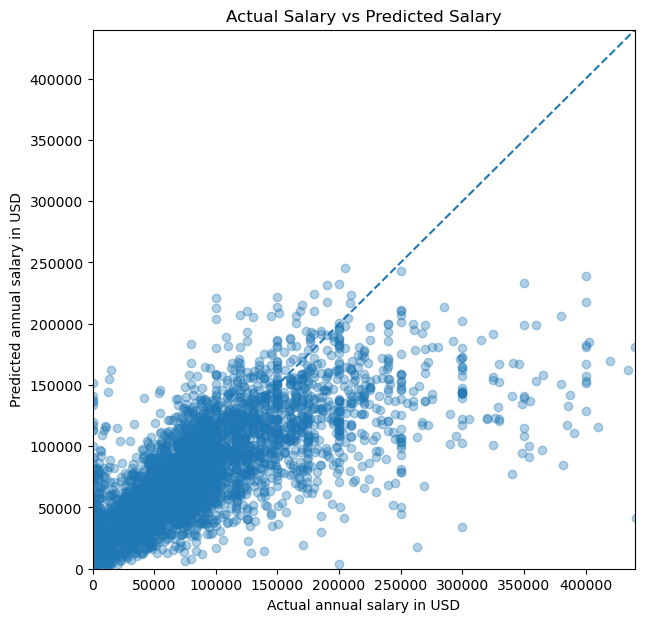

In [37]:
## Compare actual and predicted salaries
##
## The graph is limited to the 99th percentile so the typical
## prediction pattern remains visible despite extreme values.

plot_limit = y_test.quantile(
    0.99
)

plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    np.maximum(
        y_pred_tuned,
        0
    ),
    alpha=0.35
)

plt.plot(
    [0, plot_limit],
    [0, plot_limit],
    linestyle="--"
)

plt.xlim(
    0,
    plot_limit
)

plt.ylim(
    0,
    plot_limit
)

plt.title(
    "Actual Salary vs Predicted Salary"
)

plt.xlabel(
    "Actual annual salary in USD"
)

plt.ylabel(
    "Predicted annual salary in USD"
)

plt.show()

## 5.4 Save the Final Model and Preprocessing Objects

In [39]:
## Save everything needed to reproduce the same preprocessing
## in the Streamlit application

model_package = {
    "model": best_model,
    "target_transform": "log1p",
    "candidate_features": candidate_features,
    "columns_removed_after_split": columns_to_remove,
    "numerical_columns": numerical_columns,
    "categorical_columns": categorical_columns,
    "multiselect_columns": multiselect_columns,
    "training_medians": training_medians,
    "categorical_encoded_columns": (
        x_train_categorical.columns.tolist()
    ),

    "final_encoded_columns": (
        x_train_encoded.columns.tolist()
    ),
    "scaler": scaler,
    "pca": pca
}

joblib.dump(
    model_package,
    "salary_pca_model.pkl"
)

print(
    "Saved salary_pca_model.pkl"
)

Saved salary_pca_model.pkl


# 6. Iteration Conclusion

After running the notebook, compare this iteration with the first basic iteration.

Focus on:

- Number of features before and after PCA.
- Percentage of variance retained.
- MAE and Median Absolute Error.
- RMSE and R².
- Improvement over the median baseline.
- Whether the increased feature diversity actually improves unseen test performance.
- Whether the final feature requirements are practical for the Streamlit application.

If PCA reduces the feature count but produces worse test results, it should remain a documented experiment rather than the final selected model.